# From permutation matrices to splitting couplings

This notebook generates `fig:kantorovich-permutation-versus-splitting`.  With equal numbers of atoms and uniform masses, an optimal coupling can be a permutation matrix.  With unequal target masses, the same relaxation allows a source atom to split and several sources to merge into one target atom.

In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from scipy.optimize import linear_sum_assignment

from figure_style import (
    BLUE,
    DIRAC_MARKER_SIZE,
    GRAY,
    LIGHT_GRAY,
    RED,
    VIOLET,
    box_axes,
    canonical_matching_clouds,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
np.random.seed(0)

POINT_SIZE = 10.5
POINT_SIZE_LARGE = 12.0


def active_pairs(P, threshold=1e-11):
    return [(i, j, float(P[i, j])) for i in range(P.shape[0]) for j in range(P.shape[1]) if P[i, j] > threshold]


def mass_sizes(weights, base=POINT_SIZE_LARGE):
    weights = np.asarray(weights, dtype=float)
    weights = weights / max(weights.max(), 1e-15)
    return base * (0.58 + 1.25 * np.sqrt(weights))


def draw_clouds(ax, x, y, a=None, b=None, *, alpha=1.0, size=POINT_SIZE, zorder=4):
    sx = np.full(len(x), size) if a is None else mass_sizes(a, base=size)
    sy = np.full(len(y), size) if b is None else mass_sizes(b, base=size)
    ax.scatter(x[:, 0], x[:, 1], s=sx, marker="o", color=RED, alpha=alpha, edgecolor="none", zorder=zorder)
    ax.scatter(y[:, 0], y[:, 1], s=sy, marker="o", color=BLUE, alpha=alpha, edgecolor="none", zorder=zorder)


def set_cloud_limits(ax, x, y, pad=0.18):
    (xmin, xmax), (ymin, ymax) = padded_limits(np.vstack([x, y]), pad=pad)
    span = max(xmax - xmin, ymax - ymin)
    cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
    ax.set_xlim(cx - span / 2, cx + span / 2)
    ax.set_ylim(cy - span / 2, cy + span / 2)
    ax.set_aspect("equal")
    remove_axes(ax)


def draw_straight_segments(ax, x, y, pairs, *, color=VIOLET, min_width=0.12, max_width=1.20, alpha=0.55, zorder=1):
    if not pairs:
        return
    masses = np.array([m for _, _, m in pairs], dtype=float)
    rel = masses / max(masses.max(), 1e-15)
    segments = [[x[i], y[j]] for i, j, _ in pairs]
    base = np.array(to_rgb(color))
    colors = [(*base, min(alpha * (0.22 + 0.78 * np.sqrt(r)), 0.9)) for r in rel]
    widths = min_width + (max_width - min_width) * np.sqrt(rel)
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=widths, zorder=zorder))


def draw_curved_segments(ax, x, y, pairs, *, color=VIOLET, min_width=0.10, max_width=1.20, alpha=0.55, curvature=0.11, zorder=1):
    if not pairs:
        return
    masses = np.array([m for _, _, m in pairs], dtype=float)
    rel = masses / max(masses.max(), 1e-15)
    base = np.array(to_rgb(color))
    curves, colors, widths = [], [], []
    for (i, j, _), r in zip(pairs, rel):
        p, q = x[i], y[j]
        mid = 0.5 * (p + q)
        direction = q - p
        normal = np.array([-direction[1], direction[0]])
        norm = np.linalg.norm(normal)
        if norm > 1e-12:
            normal = normal / norm
        sign = -1 if ((i + 2 * j) % 2) else 1
        control = mid + sign * curvature * normal * np.linalg.norm(direction)
        ts = np.linspace(0, 1, 16)
        curve = ((1 - ts)[:, None] ** 2) * p + (2 * (1 - ts) * ts)[:, None] * control + (ts[:, None] ** 2) * q
        curves.append(curve)
        colors.append((*base, min(alpha * (0.22 + 0.78 * np.sqrt(r)), 0.88)))
        widths.append(min_width + (max_width - min_width) * np.sqrt(r))
    ax.add_collection(LineCollection(curves, colors=colors, linewidths=widths, zorder=zorder))

## Two transport polytopes

The left pair of panels uses twelve red and twelve blue atoms and therefore admits a permutation solution.  The right pair uses the same canonical geometry but only eight weighted target atoms, forcing a genuinely non-permutation coupling.

In [2]:
fig_name = "kantorovich-permutation-versus-splitting"
out = figure_dir(fig_name)

x_perm, y_perm, _ = canonical_matching_clouds(seed=2031, n_source=12)
a_perm = np.ones(len(x_perm)) / len(x_perm)
b_perm = np.ones(len(y_perm)) / len(y_perm)
C_perm = ot.dist(x_perm, y_perm, metric="euclidean") ** 2
P_perm = ot.emd(a_perm, b_perm, C_perm, numItermax=200000)

x_split, y_split, _ = canonical_matching_clouds(seed=2031, n_source=12, target_counts=(3, 3, 2))
a_split = np.ones(len(x_split)) / len(x_split)
raw = np.array([0.16, 0.13, 0.10, 0.18, 0.11, 0.16, 0.09, 0.08])
b_split = raw / raw.sum()
C_split = ot.dist(x_split, y_split, metric="euclidean") ** 2
P_split = ot.emd(a_split, b_split, C_split, numItermax=200000)

## Matrix and geometry panels

The matrix panels show the coupling coefficients.  The geometry panels draw the same positive coefficients as transport segments between circular atoms; target marker sizes encode nonuniform masses in the splitting example.

In [3]:
cmap = LinearSegmentedColormap.from_list("ot4ml_coupling", ["#ffffff", "#f1e4f2", VIOLET])
vmax = max(P_perm.max(), P_split.max())


def draw_matrix(P, path, figsize):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(P, cmap=cmap, vmin=0, vmax=vmax, interpolation="nearest", aspect="auto")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-0.5, P.shape[1] - 0.5)
    ax.set_ylim(P.shape[0] - 0.5, -0.5)
    box_axes(ax)
    save_pdf(fig, path, pad_inches=0.025)
    plt.close(fig)


def draw_transport_panel(x, y, P, a, b, path):
    fig, ax = plt.subplots(figsize=(2.05, 2.05))
    draw_straight_segments(ax, x, y, active_pairs(P), color=VIOLET, min_width=0.16, max_width=1.20, alpha=0.64, zorder=1)
    draw_clouds(ax, x, y, a=a, b=b, size=POINT_SIZE, zorder=3)
    set_cloud_limits(ax, x, y, pad=0.18)
    save_pdf(fig, path)
    plt.close(fig)


draw_matrix(P_perm, out / "permutation-matrix.pdf", figsize=(1.85, 2.05))
draw_transport_panel(x_perm, y_perm, P_perm, a_perm, b_perm, out / "permutation-transport.pdf")
draw_matrix(P_split, out / "splitting-matrix.pdf", figsize=(1.65, 2.05))
draw_transport_panel(x_split, y_split, P_split, a_split, b_split, out / "splitting-transport.pdf")

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


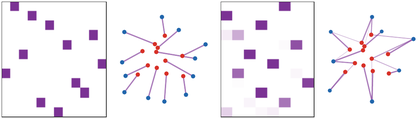

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/kantorovich-permutation-versus-splitting.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/kantorovich-permutation-versus-splitting.png")
display(Image(filename=str(_thumb)))
